In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,precision_score, recall_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [37]:
# Load dataset
df = pd.read_csv('/content/Churn_Modelling.csv')

In [38]:
df.shape

(10000, 14)

In [39]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# 🔍 Step 3: Exploratory Data Analysis (EDA)

We explore the dataset to understand its structure, distributions, and relationships.

In [40]:
 print("DATASET INFO:\n")

df.info()

DATASET INFO:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [41]:
print("MISSING VALUES:\n")
df.isnull().sum()

MISSING VALUES:



,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [42]:
print("DUPLICATE ROWS:\n")
df.duplicated().sum()

DUPLICATE ROWS:



np.int64(0)

In [43]:
print("Statistical Summary of Numerical Features:\n")
df.describe().round(2) #round all numerical values to 2 decimal places

Statistical Summary of Numerical Features:



,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,5000.50,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,2886.90,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,1.00,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,2500.75,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,5000.50,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,7500.25,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,10000.00,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [44]:
print("Target Variable Distribution (Exited):")
print(df['Exited'].value_counts())
print(f"Churn rate = {df['Exited'].mean()*100:.2f}%")

Target Variable Distribution (Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64
Churn rate = 20.37%


Text(0, 0.5, '')

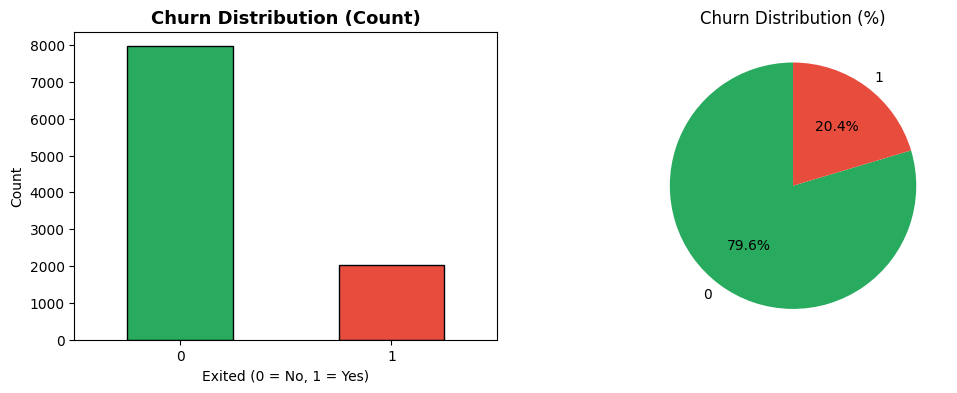

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#28ab5e", '#e74c3c']
df['Exited'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', rot=0)
axes[0].set_title('Churn Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Exited (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')
df['Exited'].value_counts().plot(
    kind='pie',
    ax=axes[1],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

axes[1].set_title('Churn Distribution (%)')
axes[1].set_ylabel('')


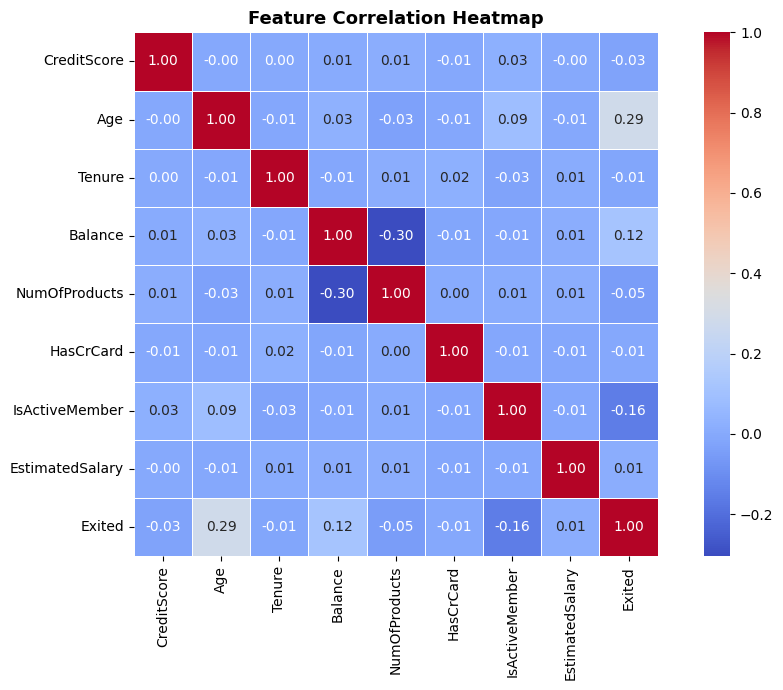

In [46]:
# Correlation Heatmap (numerical columns only)
num_df = df.select_dtypes(include=[np.number]).drop(columns=['RowNumber', 'CustomerId'])

plt.figure(figsize=(10, 7))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#  Step 4: Data Preprocessing

## Steps:
1. Drop irrelevant columns (RowNumber, CustomerId, Surname)
2. One-Hot Encode categorical columns (Geography, Gender)
3. Split into features (X) and target (y)
4. Train-Test Split (80:20)
5. Feature Scaling with StandardScaler

In [47]:
# Drop irrelevant columns
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])


In [48]:
print("Columns after dropping irrelevant ones:", list(df_clean.columns))

Columns after dropping irrelevant ones: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [49]:
df_encoded = pd.get_dummies(df_clean, columns=['Geography', 'Gender'], drop_first=True).astype(int)


In [50]:
df_encoded

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0,2,1,0,96270,0,0,0,1
9996,516,35,10,57369,1,1,1,101699,0,0,0,1
9997,709,36,7,0,1,0,1,42085,1,0,0,0
9998,772,42,3,75075,2,1,0,92888,1,1,0,1


In [51]:
# Define Features (X) and Target (y)
X = df_encoded.drop(columns = ['Exited'])
y = df_encoded['Exited']


In [52]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,0,0,0
1,608,41,1,83807,1,0,1,112542,0,1,0
2,502,42,8,159660,3,1,0,113931,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0
4,850,43,2,125510,1,1,1,79084,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0,2,1,0,96270,0,0,1
9996,516,35,10,57369,1,1,1,101699,0,0,1
9997,709,36,7,0,1,0,1,42085,0,0,0
9998,772,42,3,75075,2,1,0,92888,1,0,1


In [53]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [54]:
# Train-Test Split (80% train, 20% test)

X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state= 42, stratify = y
)

In [55]:
# Feature Scaling using StandardScaler
# IMPORTANT: Fit only on training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
X_train_scaled.shape[1]

11

In [57]:
print(X_train_scaled.shape)
X_train_scaled

(8000, 11)


array([[ 1.058568  ,  1.71508648,  0.68472287, ..., -0.57831252,
        -0.57773517,  0.90750738],
       [ 0.91362605, -0.65993547, -0.6962018 , ...,  1.72916886,
        -0.57773517,  0.90750738],
       [ 1.07927399, -0.18493108, -1.73189531, ...,  1.72916886,
        -0.57773517, -1.10191942],
       ...,
       [ 0.16821031, -0.18493108,  1.3751852 , ..., -0.57831252,
        -0.57773517, -1.10191942],
       [ 0.37527024, -0.37493284,  1.02995403, ..., -0.57831252,
         1.73089688,  0.90750738],
       [ 1.56586482,  1.14508121,  0.68472287, ..., -0.57831252,
         1.73089688,  0.90750738]])

# Build the ANN Model
## Architecture:
- **Input Layer:** 11 features
- **Hidden Layer 1:** 16 neurons, ReLU activation
- **Dropout Layer 1:** 20% dropout (regularization to prevent overfitting)
- **Hidden Layer 2:** 8 neurons, ReLU activation
- **Dropout Layer 2:** 20% dropout
- **Output Layer:** 1 neuron, Sigmoid activation (binary classification)

## Why these choices?
- **ReLU** avoids vanishing gradient problem in hidden layers
- **Sigmoid** in output gives probability between 0 and 1
- **Dropout** prevents overfitting by randomly disabling neurons during training
- **Binary Crossentropy** is the standard loss for binary classification
- **Adam** optimizer — adaptive learning rate, works well in practice

In [58]:
model = Sequential()
model.add(Dense(16, activation = 'relu', input_dim = 11))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [59]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373 (1.46 KB)

 Trainable params: 373 (1.46 KB)

 Non-trainable params: 0 (0.00 B)

## Compilation Of Model

In [60]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy', 'precision', 'recall']
)


# Train the Model

In [61]:
# Early Stopping — stop training when validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,          # Wait 10 epochs before stopping
    restore_best_weights=True  # Use weights from the best epoch
)

#train the model

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,    # 10% of training data used for validation
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch: {len(history.history['loss'])}")

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7353 - loss: 0.5403 - precision: 0.2298 - recall: 0.1231 - val_accuracy: 0.8087 - val_loss: 0.4293 - val_precision: 0.4000 - val_recall: 0.0132
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7992 - loss: 0.4469 - precision: 0.6096 - recall: 0.0602 - val_accuracy: 0.8225 - val_loss: 0.4081 - val_precision: 0.6923 - val_recall: 0.1184
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8118 - loss: 0.4308 - precision: 0.6565 - recall: 0.1746 - val_accuracy: 0.8300 - val_loss: 0.3979 - val_precision: 0.7000 - val_recall: 0.1842
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8218 - loss: 0.4197 - precision: 0.6857 - recall: 0.2436 - val_accuracy: 0.8300 - val_loss: 0.3867 - val_precision: 0.6600 - val_recall: 0.2171
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8285 - loss: 0.4084 - precision: 0.6957 - recall: 0.2923 - val_accuracy: 0.8350 - val_los

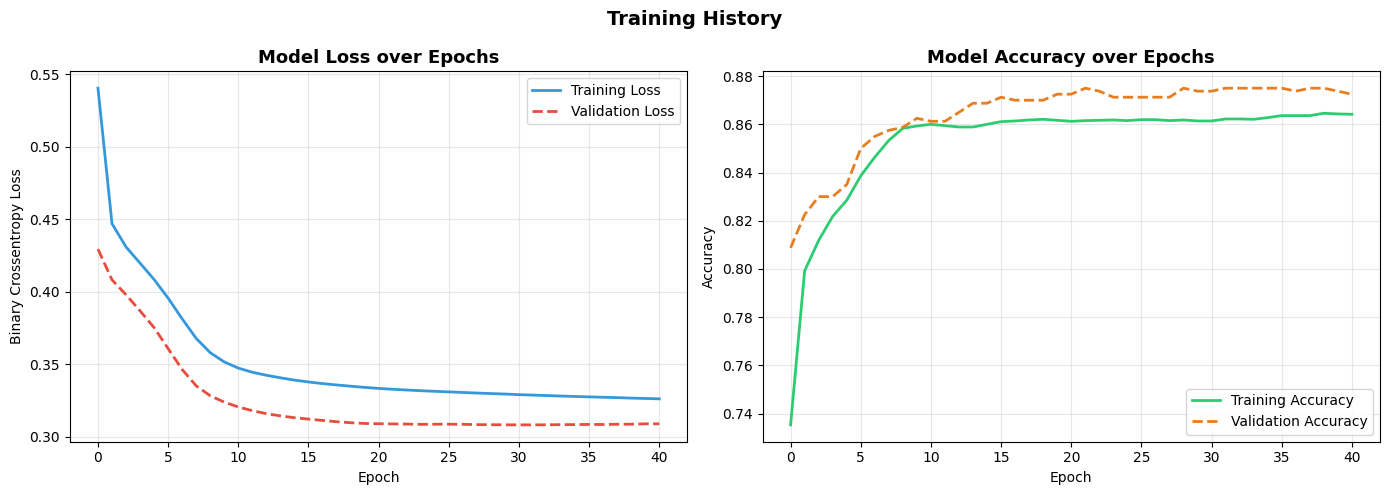

In [62]:
# Plot Training History — Loss and Accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
axes[0].plot(history.history['loss'], label='Training Loss', color='#3498db', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('Model Loss over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy Curve
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='#2ecc71', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#e67e22', linewidth=2, linestyle='--')
axes[1].set_title('Model Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Model Evaluation
We evaluate the model using multiple metrics:
- **Accuracy** — overall correctness
- **Confusion Matrix** — breakdown of predictions vs actuals
- **Classification Report** — Precision, Recall, F1-score per class
- **ROC-AUC Score** — model's ability to distinguish between classes

In [63]:
# Get predictions
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# key Metrics

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)

print(" MODEL EVALUATION RESULTS\n")

print(f" Accuracy Score : {acc * 100:.2f}%")
print(f" ROC-AUC Score  : {roc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Churned (1)']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
 MODEL EVALUATION RESULTS

 Accuracy Score : 85.75%
 ROC-AUC Score  : 0.8590

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.88      0.96      0.91      1593
 Churned (1)       0.73      0.47      0.57       407

    accuracy                           0.86      2000
   macro avg       0.80      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



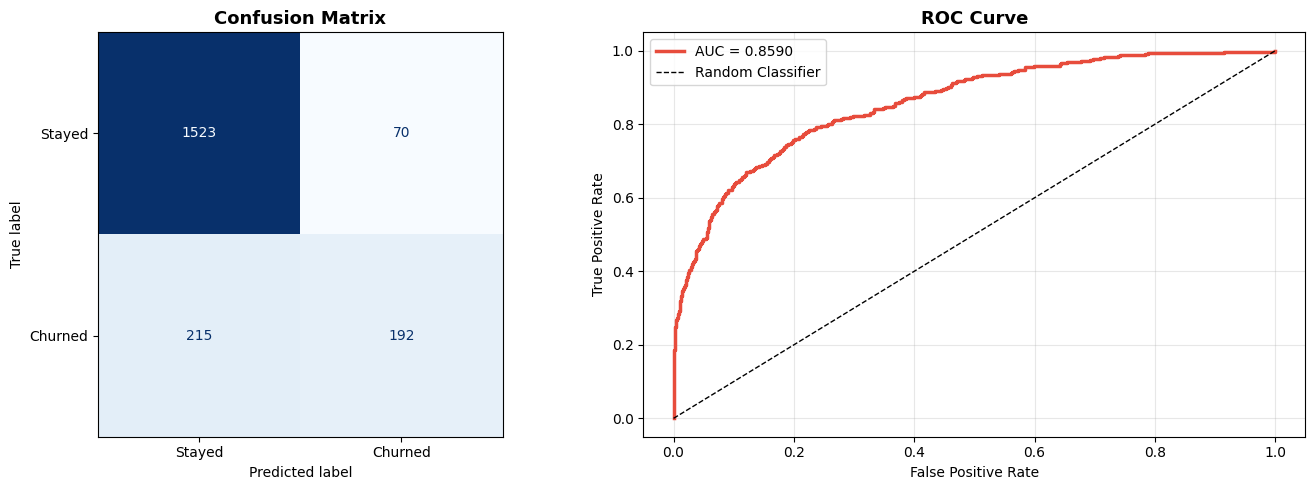

In [64]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'AUC = {roc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
# Step 8: Feature Importance (Weight-based)

We analyze which input features have the highest influence on the ANN's output by examining the absolute weights of the first layer.

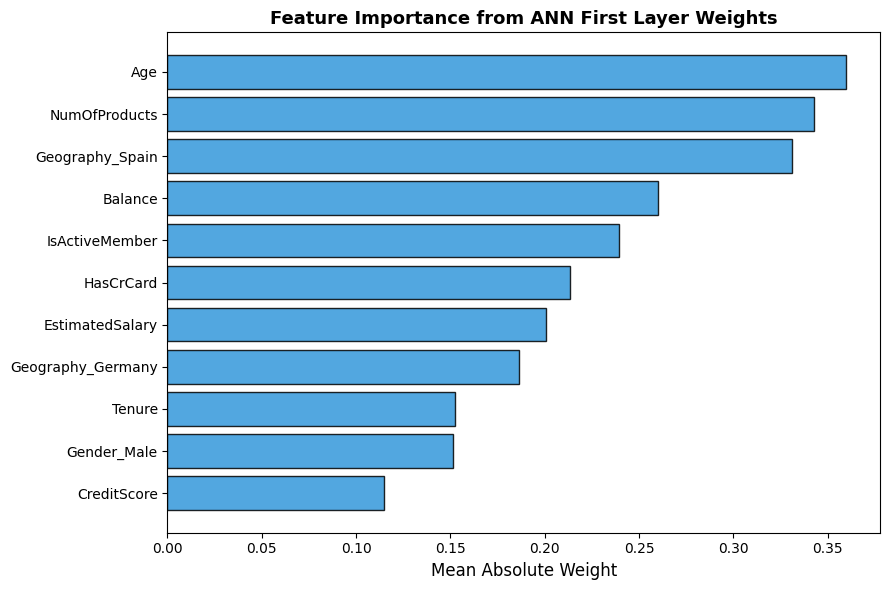


Top 3 most important features:
        Feature  Importance
            Age    0.359734
  NumOfProducts    0.342695
Geography_Spain    0.331143


In [65]:
# Extract weights from first Dense layer

weights_layer1 = model.layers[0].get_weights()[0]  # shape: (n_features, n_neurons)
importance = np.abs(weights_layer1).mean(axis=1)   # Average absolute weight per feature

feature_names = list(X.columns)
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                color='#3498db', edgecolor='black', alpha=0.85)
plt.xlabel('Mean Absolute Weight', fontsize=12)
plt.title('Feature Importance from ANN First Layer Weights', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
print(importance_df.sort_values('Importance', ascending=False).head(3).to_string(index=False))

---
# Predict on a New Customer

Let's test the model on a new, unseen customer profile.

In [66]:
# Example: New customer profile
# Features (after encoding):
# CreditScore, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember,
# EstimatedSalary, Geography_Germany, Geography_Spain, Gender_Male

new_customer = np.array([[600, 40, 3, 60000, 2, 1, 1, 50000, 1, 0, 1]])

# Scale using the already fitted scaler
new_customer_scaled = scaler.transform(new_customer)

# Predict
churn_probability = model.predict(new_customer_scaled)[0][0]
prediction = 'Will CHURN 🔴' if churn_probability > 0.5 else 'Will STAY 🟢'

print(f"Churn Probability : {churn_probability * 100:.2f}%")
print(f"Prediction        : {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Churn Probability : 10.43%
Prediction        : Will STAY 🟢
